In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [4]:
data_path = '/content/drive/MyDrive/earbud_review_intelligence/data/processed/earbuds_reviews_clean.csv'

#Import modules

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

**Initializing dataset**

In [7]:
df = pd.read_csv(data_path,parse_dates=['review_date'])
df.head()

,asin,parent_asin,rating,review_title,review_text,timestamp,verified_purchase,helpful_vote,review_date
0,B08215Z1M5,B09DSSQ52Q,5.0,Great quality and fit!,Very sturdy and well made. My AirPods fit snug...,1619198055317,True,7,2021-04-23 17:14:15.317
1,B09K7K5J3N,B09K7K5J3N,5.0,These work Great.,These are the best and most reasonably priced ...,1646223741743,True,0,2022-03-02 12:22:21.743
2,B07S5JVP78,B07S5JVP78,4.0,Great Buds for use in an office or other simil...,These are great inexpensive ear buds. My only ...,1584569430726,True,0,2020-03-18 22:10:30.726
3,B00365EB3I,B00365EB3I,5.0,Awesome Sound Quality,The ear buds take a little getting used to - b...,1293021749000,True,1,2010-12-22 12:42:29.000
4,B01L2VGEQE,B01L2VGEQE,5.0,Works great,Product was as it was described. Didn’t come w...,1632614999311,True,1,2021-09-26 00:09:59.311


# 1. Rating distribution
**Amazon reviews typically skew heavily towards 5 star**

Text(0, 0.5, 'Number of reviews')

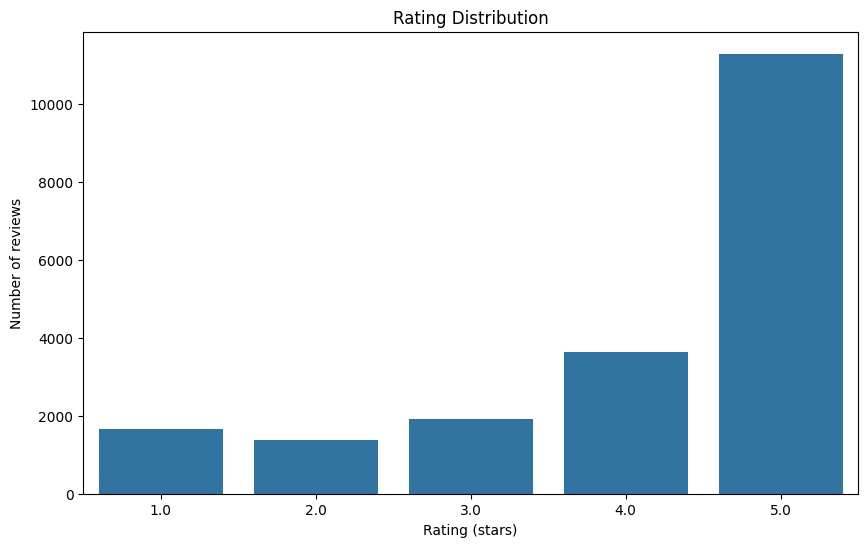

In [12]:
plt.figure(figsize=(10,6))
sns.countplot(data=df,x='rating')
plt.title("Rating Distribution")
plt.xlabel("Rating (stars)")
plt.ylabel("Number of reviews")

In [15]:
print(df['rating'].value_counts(normalize=True).sort_index()*100)

rating
1.0     8.400866
2.0     6.921025
3.0     9.593799
4.0    18.306740
5.0    56.777571
Name: proportion, dtype: float64


# 2.Review length of distribution
**this helps in turnication length later**

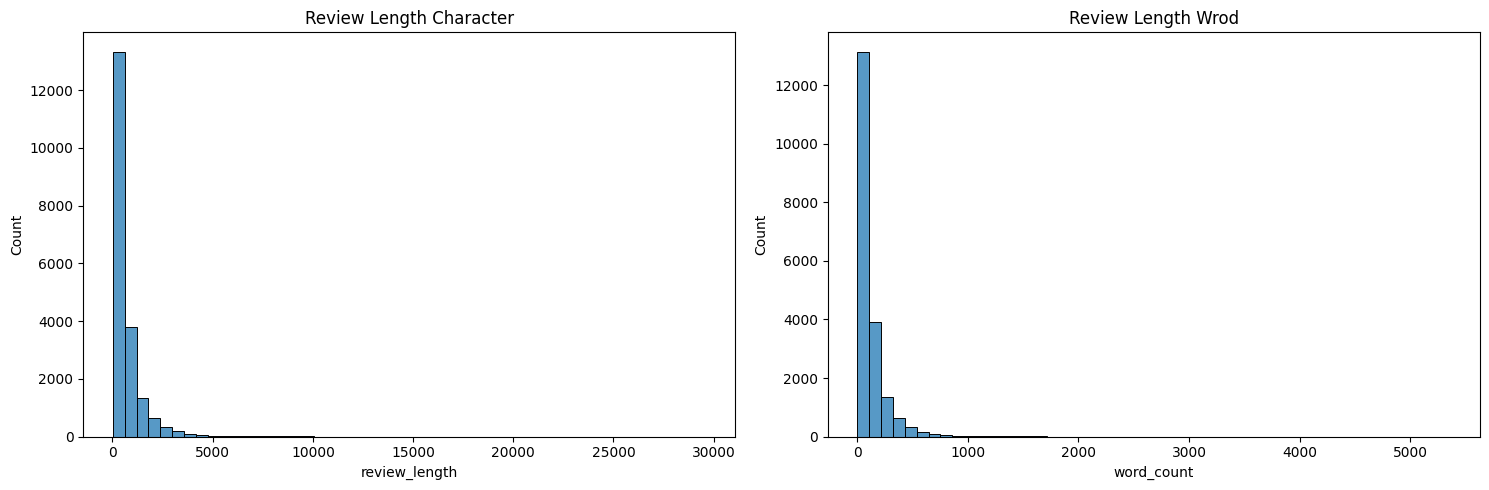

In [20]:
df['review_length'] = df['review_text'].str.len()
df['word_count'] = df['review_text'].str.split().str.len()

fig,axes = plt.subplots(1,2,figsize=(15,5))
sns.histplot(data=df,x='review_length',bins=50, ax=axes[0])
axes[0].set_title('Review Length Character')
sns.histplot(data=df,x='word_count',bins=50,ax=axes[1])
axes[1].set_title('Review Length Wrod')
plt.tight_layout()
plt.show()


In [21]:
print(df[['review_length', 'word_count']].describe())

       review_length    word_count
count   19867.000000  19867.000000
mean      652.646600    119.512659
std       890.421058    160.491277
min        15.000000      2.000000
25%       189.000000     35.000000
50%       383.000000     72.000000
75%       774.000000    143.000000
max     29605.000000   5361.000000


# 3. Review Volume Overtime

Tells use whether we have usefull data of recent years

/tmp/ipykernel_694/3341788861.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_count = df.groupby(pd.Grouper(key='review_date', freq='M')).size()


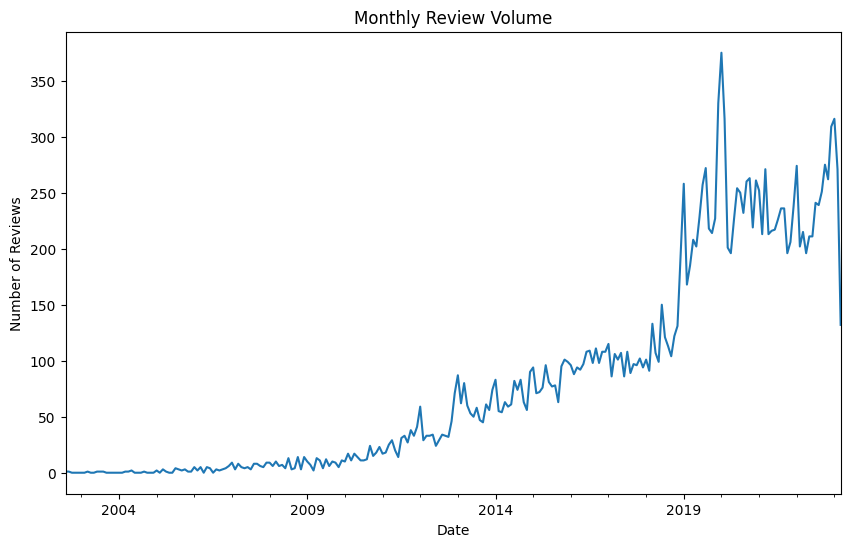

In [29]:
monthly_count = df.groupby(pd.Grouper(key='review_date', freq='M')).size()

plt.figure(figsize=(10,6))
monthly_count.plot()
plt.title('Monthly Review Volume')
plt.xlabel('Date')
plt.ylabel('Number of Reviews')
plt.show()

# 4. Most common words
before creating the aspect extraction step this gives a brief info vocabalary usage

In [30]:
!pip install wordcloud -q

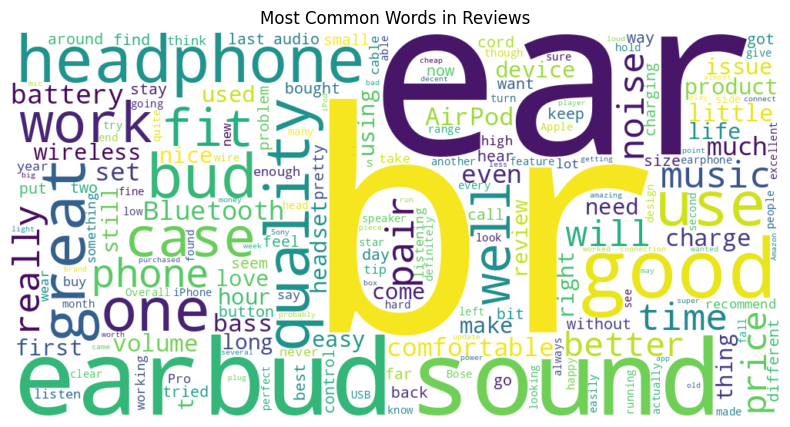

In [34]:
from wordcloud import STOPWORDS, WordCloud
text = ' '.join(df['review_text'].sample(min(5000,len(df)),random_state=43))

wc = WordCloud(width=1000,height=500, background_color='white',
               stopwords = STOPWORDS, collocations=False).generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Reviews')
plt.show()

# 5. Ratings vs. review length
Here we check the negative does have the long text or not cause it is a common practice for cutomers

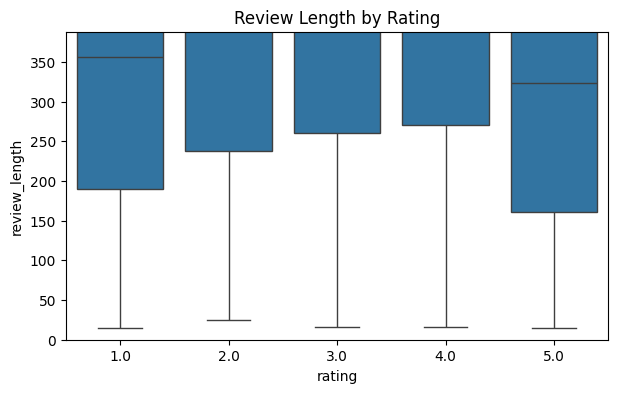

In [38]:
plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x='rating', y='review_length')
plt.title('Review Length by Rating')
plt.ylim(0, df['word_count'].quantile(0.95))
plt.show()

#Notes
- From here I got to know that we have more 5 star reviews in the data
- the other thing I noticed is the lower rating like 1-2 have more text compared to higher ratings
- From the wordcloud I got know the most used words in the dataset